# Notebook 08 — Model Tuning & Evaluation
## Section 1: Random Forest Hyperparameter Tuning (MAE)

Try a small set of RF settings and pick the best using **cross-validation MAE** on train data.

**Then:** evaluate best config once on September test set.

**Metric:** MAE only (minutes)

In [1]:
# =============================================================================
# Notebook 08 | Section 1: RF Hyperparameter Tuning (MAE)
# =============================================================================
# Small param grid → CV on train → best config → test MAE on Sep.
# Uses train sample for speed (documented in report).
# =============================================================================

from __future__ import annotations

import json
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=FutureWarning)

# --- speed settings (full train is very slow) ---
USE_TRAIN_SAMPLE = True
TRAIN_SAMPLE_SIZE = 80_000
CV_FOLDS = 3
RANDOM_STATE = 42

PRIMARY_TARGET = "delay_in_min"
CATEGORICAL_COLS = ["eva", "train_number", "final_destination_station"]

PARAM_GRID = [
    {"n_estimators": 50,  "max_depth": 12, "min_samples_leaf": 50, "max_samples": 0.3},
    {"n_estimators": 50,  "max_depth": 20, "min_samples_leaf": 10, "max_samples": 0.3},
    {"n_estimators": 100, "max_depth": 12, "min_samples_leaf": 50, "max_samples": 0.3},
    {"n_estimators": 100, "max_depth": 20, "min_samples_leaf": 10, "max_samples": 0.5},
]


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        config_file = candidate / "data" / "reference" / "project_config.json"
        if config_file.exists():
            return candidate
        nb = candidate / "Notebooks"
        if (nb / "data" / "reference" / "project_config.json").exists():
            return nb
    raise FileNotFoundError("Cannot find data/reference/project_config.json")


PROJECT_ROOT = find_project_root()
REFERENCE_DIR = PROJECT_ROOT / "data" / "reference"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

SPLIT_PATH = REFERENCE_DIR / "train_test_split_config.json"
RF_S1_PATH = REFERENCE_DIR / "random_forest_results.json"
TUNING_PATH = REFERENCE_DIR / "rf_tuning_results.json"

TRAIN_PATH = PROCESSED_DIR / "ice_train.parquet"
TEST_PATH = PROCESSED_DIR / "ice_test.parquet"


def load_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj


def build_preprocessor(feature_cols: list[str]) -> ColumnTransformer:
    cat_cols = [c for c in CATEGORICAL_COLS if c in feature_cols]
    num_cols = [c for c in feature_cols if c not in cat_cols]
    return ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), num_cols),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
                ]),
                cat_cols,
            ),
        ]
    )


def make_pipeline(feature_cols: list[str], params: dict) -> Pipeline:
    rf_params = {**params, "random_state": RANDOM_STATE, "n_jobs": -1}
    return Pipeline([
        ("prep", build_preprocessor(feature_cols)),
        ("model", RandomForestRegressor(**rf_params)),
    ])


def tune_feature_set(name: str, feature_cols: list[str], train_df, test_df) -> dict:
    if USE_TRAIN_SAMPLE and len(train_df) > TRAIN_SAMPLE_SIZE:
        tune_df = train_df.sample(n=TRAIN_SAMPLE_SIZE, random_state=RANDOM_STATE)
    else:
        tune_df = train_df

    X_tune = tune_df[feature_cols]
    y_tune = tune_df[PRIMARY_TARGET].values
    X_test = test_df[feature_cols]
    y_test = test_df[PRIMARY_TARGET].values

    print(f"--- Tuning: {name} ({len(feature_cols)} features) ---")
    print(f"CV sample rows: {len(tune_df):,} | Test rows: {len(test_df):,}")
    print()

    cv_results = []
    for i, params in enumerate(PARAM_GRID, start=1):
        pipe = make_pipeline(feature_cols, params)
        scores = cross_val_score(
            pipe,
            X_tune,
            y_tune,
            cv=CV_FOLDS,
            scoring="neg_mean_absolute_error",
            n_jobs=-1,
        )
        cv_mae = round(float(-scores.mean()), 4)
        cv_std = round(float(scores.std()), 4)
        print(f"  [{i}/{len(PARAM_GRID)}] {params} → CV MAE = {cv_mae:.4f} (+/- {cv_std:.4f})")
        cv_results.append({
            "params": params,
            "cv_mae_mean": cv_mae,
            "cv_mae_std": cv_std,
        })

    best = min(cv_results, key=lambda x: x["cv_mae_mean"])
    best_params = best["params"]

    print()
    print(f"  Best CV params: {best_params}")
    print(f"  Best CV MAE   : {best['cv_mae_mean']:.4f}")
    print()

    # Refit best on full train (or sample if still too slow)
    fit_df = train_df.sample(n=min(len(train_df), 120_000), random_state=RANDOM_STATE) if USE_TRAIN_SAMPLE else train_df
    best_pipe = make_pipeline(feature_cols, best_params)
    print(f"  Refitting best model on {len(fit_df):,} train rows...")
    best_pipe.fit(fit_df[feature_cols], fit_df[PRIMARY_TARGET].values)

    test_mae = round(float(mean_absolute_error(y_test, best_pipe.predict(X_test))), 4)
    print(f"  Final test MAE (Sep): {test_mae:.4f} min")
    print()

    return {
        "feature_set_name": name,
        "feature_cols": feature_cols,
        "cv_results": cv_results,
        "best_params": best_params,
        "best_cv_mae": best["cv_mae_mean"],
        "test_mae": test_mae,
        "train_rows_for_final_fit": int(len(fit_df)),
        "tune_sample_rows": int(len(tune_df)),
    }


# =============================================================================
# RUN
# =============================================================================
split_cfg = load_json(SPLIT_PATH)
rf_s1 = load_json(RF_S1_PATH) if RF_S1_PATH.exists() else {}

operational = split_cfg["feature_sets_for_ablation"]["operational_only"]
full_wx = split_cfg["feature_sets_for_ablation"]["full_with_weather"]

print("Notebook 08 | Section 1 — RF tuning (MAE)")
print(f"Param combos: {len(PARAM_GRID)} | CV folds: {CV_FOLDS}")
print(f"USE_TRAIN_SAMPLE={USE_TRAIN_SAMPLE}, size={TRAIN_SAMPLE_SIZE:,}")
print()

train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

tuning_results = [
    tune_feature_set("operational_only", operational, train_df, test_df),
    tune_feature_set("full_with_weather", full_wx, train_df, test_df),
]

best_op = tuning_results[0]
best_full = tuning_results[1]
weather_gain = round(best_op["test_mae"] - best_full["test_mae"], 4)

# Compare to Notebook 07 Section 2 untuned RF
untuned_op = rf_s1.get("rq_notes", {}).get("RQ1_rf_operational_test_mae")
untuned_full = rf_s1.get("rq_notes", {}).get("RQ2_rf_full_test_mae")
naive_median = rf_s1.get("comparison", {}).get("naive_median_test_mae")

print("=" * 72)
print("TUNING SUMMARY")
print("=" * 72)
print(f"{'Feature set':<22} {'CV MAE':>10} {'Test MAE':>10}")
for r in tuning_results:
    print(f"{r['feature_set_name']:<22} {r['best_cv_mae']:>10.4f} {r['test_mae']:>10.4f}")
print()
print(f"Weather gain (op - full): {weather_gain:.4f} min")
if untuned_op:
    print(f"Untuned RF op MAE (NB07): {untuned_op:.4f} → tuned: {best_op['test_mae']:.4f}")
if naive_median:
    print(f"Naive median MAE       : {naive_median:.4f}")
print()

report = {
    "metadata": {
        "notebook": "08_Model_Tuning_and_Evaluation",
        "section": "Section 1",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "primary_metric": "mae",
        "tuning_method": "manual_grid + cross_val_score on train sample",
        "use_train_sample": USE_TRAIN_SAMPLE,
        "train_sample_size": TRAIN_SAMPLE_SIZE,
        "cv_folds": CV_FOLDS,
        "param_grid": PARAM_GRID,
    },
    "tuning_results": tuning_results,
    "comparison": {
        "weather_gain_test_mae": weather_gain,
        "untuned_rf_operational_test_mae": untuned_op,
        "untuned_rf_full_test_mae": untuned_full,
        "naive_median_test_mae": naive_median,
    },
    "best_overall_tuned": min(tuning_results, key=lambda x: x["test_mae"]),
}

with TUNING_PATH.open("w", encoding="utf-8") as f:
    json.dump(make_json_safe(report), f, indent=2, ensure_ascii=False)

print("=" * 72)
print("Section 1 COMPLETE")
print("=" * 72)
print(f"Saved: {TUNING_PATH}")
print("Next: Section 2 — formal weather ablation + final model choice")
print("=" * 72)

Notebook 08 | Section 1 — RF tuning (MAE)
Param combos: 4 | CV folds: 3
USE_TRAIN_SAMPLE=True, size=80,000

--- Tuning: operational_only (9 features) ---
CV sample rows: 80,000 | Test rows: 121,964

  [1/4] {'n_estimators': 50, 'max_depth': 12, 'min_samples_leaf': 50, 'max_samples': 0.3} → CV MAE = 10.5474 (+/- 0.0582)
  [2/4] {'n_estimators': 50, 'max_depth': 20, 'min_samples_leaf': 10, 'max_samples': 0.3} → CV MAE = 10.2468 (+/- 0.0413)
  [3/4] {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 50, 'max_samples': 0.3} → CV MAE = 10.5440 (+/- 0.0536)
  [4/4] {'n_estimators': 100, 'max_depth': 20, 'min_samples_leaf': 10, 'max_samples': 0.5} → CV MAE = 10.1959 (+/- 0.0616)

  Best CV params: {'n_estimators': 100, 'max_depth': 20, 'min_samples_leaf': 10, 'max_samples': 0.5}
  Best CV MAE   : 10.1959

  Refitting best model on 120,000 train rows...
  Final test MAE (Sep): 10.4222 min

--- Tuning: full_with_weather (15 features) ---
CV sample rows: 80,000 | Test rows: 121,964

  [1

# Notebook 08 — Model Tuning & Evaluation
## Section 2: Weather Ablation & Final Model Selection

Build the full MAE leaderboard from:
- Notebook 07 Section 1 (linear family + Lasso/ElasticNet)
- Notebook 07 Section 2 (Random Forest)
- Notebook 07 Section 3 (GradientBoosting / XGBoost / LightGBM)
- Notebook 08 Section 1 (tuned Random Forest)

Then:
1. Formal weather ablation on tuned RF (RQ2)  
2. Pick **best ML model overall** for Notebook 09 export  

**Metric:** MAE (minutes) on September test set

Notebook 08 | Section 2 — Weather ablation + final model

WEATHER ABLATION — Tuned Random Forest (same best params)
Best params: {'n_estimators': 100, 'max_depth': 20, 'min_samples_leaf': 10, 'max_samples': 0.5}

Model                               Features   Test MAE
Tuned RF operational only                  9    10.4222
Tuned RF + weather                        15    10.4196

Weather gain (operational - full): 0.0026 min
Weather helps? YES

FULL LEADERBOARD (Sep test MAE — lower is better)
             stage              model       feature_set  test_mae
             Naive        NaiveMedian              none    9.4813
  NB07-S3 Boosting            XGBoost full_with_weather   10.3111
  NB07-S3 Boosting           LightGBM full_with_weather   10.3389
  NB07-S3 Boosting   GradientBoosting full_with_weather   10.3750
     NB08 Tuned RF RandomForest_Tuned full_with_weather   10.4196
     NB08 Tuned RF RandomForest_Tuned  operational_only   10.4222
NB07-S2 RF untuned       RandomForest  o

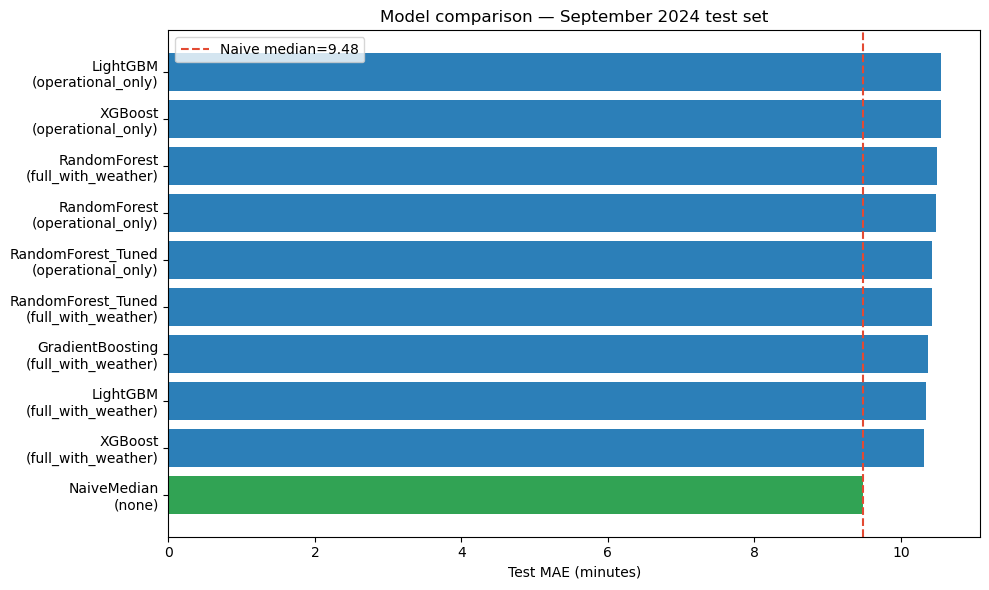

Section 2 COMPLETE
Final model : XGBoost (full_with_weather)
Final MAE   : 10.3111 min
Saved       : c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\reference\final_model_selection.json
Ablation    : c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\reference\weather_ablation_report.json
Chart       : c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\processed\figures\final_model_mae_comparison.png

Next: Section 3 — Notebook 08 close-out


In [2]:
# =============================================================================
# Notebook 08 | Section 2: Weather Ablation & Final Model Selection
# =============================================================================
# Load tuning + baseline + RF + boosting → leaderboard → pick final model.
# Saves weather_ablation_report.json + final_model_selection.json
# =============================================================================

from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        config_file = candidate / "data" / "reference" / "project_config.json"
        if config_file.exists():
            return candidate
        nb = candidate / "Notebooks"
        if (nb / "data" / "reference" / "project_config.json").exists():
            return nb
    raise FileNotFoundError("Cannot find data/reference/project_config.json")


PROJECT_ROOT = find_project_root()
REFERENCE_DIR = PROJECT_ROOT / "data" / "reference"
FIGURES_DIR = PROJECT_ROOT / "data" / "processed" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TUNING_PATH = REFERENCE_DIR / "rf_tuning_results.json"
BASELINE_PATH = REFERENCE_DIR / "baseline_results.json"
RF_S1_PATH = REFERENCE_DIR / "random_forest_results.json"
BOOSTING_PATH = REFERENCE_DIR / "boosting_results.json"
SPLIT_PATH = REFERENCE_DIR / "train_test_split_config.json"
ABLATION_PATH = REFERENCE_DIR / "weather_ablation_report.json"
FINAL_MODEL_PATH = REFERENCE_DIR / "final_model_selection.json"
CHART_PATH = FIGURES_DIR / "final_model_mae_comparison.png"


def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}\nRun prior sections first.")
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj


print("Notebook 08 | Section 2 — Weather ablation + final model")
print()

tuning = load_json(TUNING_PATH)
baseline = load_json(BASELINE_PATH)
rf_s1 = load_json(RF_S1_PATH)
boosting = load_json(BOOSTING_PATH)
split_cfg = load_json(SPLIT_PATH)

tuned_op = next(r for r in tuning["tuning_results"] if r["feature_set_name"] == "operational_only")
tuned_full = next(r for r in tuning["tuning_results"] if r["feature_set_name"] == "full_with_weather")

naive_median = baseline["naive_reference"]["naive_median_test_mae"]
naive_mean = baseline["naive_reference"]["naive_mean_test_mae"]

# =============================================================================
# 1) FORMAL WEATHER ABLATION (RQ2) — tuned RF
# =============================================================================
print("=" * 72)
print("WEATHER ABLATION — Tuned Random Forest (same best params)")
print("=" * 72)
print(f"Best params: {tuned_full['best_params']}")
print()
print(f"{'Model':<35} {'Features':>8} {'Test MAE':>10}")
print(f"{'Tuned RF operational only':<35} {len(tuned_op['feature_cols']):>8} {tuned_op['test_mae']:>10.4f}")
print(f"{'Tuned RF + weather':<35} {len(tuned_full['feature_cols']):>8} {tuned_full['test_mae']:>10.4f}")
print()

weather_gain = round(tuned_op["test_mae"] - tuned_full["test_mae"], 4)
print(f"Weather gain (operational - full): {weather_gain:.4f} min")
print(f"Weather helps? {'YES' if weather_gain > 0 else 'NO (tiny or no gain)'}")
print()

# =============================================================================
# 2) FULL PROJECT LEADERBOARD
# =============================================================================
leaderboard_rows = [
    {"stage": "Naive", "model": "NaiveMedian", "feature_set": "none", "test_mae": naive_median},
    {"stage": "Naive", "model": "NaiveMean", "feature_set": "none", "test_mae": naive_mean},
]

for r in baseline["results"]:
    if r["model"] in ("NaiveMean", "NaiveMedian"):
        continue
    leaderboard_rows.append(
        {
            "stage": "NB07-S1 Linear",
            "model": r["model"],
            "feature_set": r["feature_set"],
            "test_mae": r["test_mae"],
        }
    )

for r in rf_s1["results"]:
    leaderboard_rows.append(
        {
            "stage": "NB07-S2 RF untuned",
            "model": r["model"],
            "feature_set": r["feature_set"],
            "test_mae": r["test_mae"],
        }
    )

for r in boosting["results"]:
    leaderboard_rows.append(
        {
            "stage": "NB07-S3 Boosting",
            "model": r["model"],
            "feature_set": r["feature_set"],
            "test_mae": r["test_mae"],
        }
    )

leaderboard_rows.extend(
    [
        {
            "stage": "NB08 Tuned RF",
            "model": "RandomForest_Tuned",
            "feature_set": "operational_only",
            "test_mae": tuned_op["test_mae"],
        },
        {
            "stage": "NB08 Tuned RF",
            "model": "RandomForest_Tuned",
            "feature_set": "full_with_weather",
            "test_mae": tuned_full["test_mae"],
        },
    ]
)

lb_df = pd.DataFrame(leaderboard_rows).sort_values("test_mae")
best_overall = lb_df.iloc[0]
best_ml = lb_df[~lb_df["model"].isin(["NaiveMedian", "NaiveMean"])].iloc[0]

print("=" * 72)
print("FULL LEADERBOARD (Sep test MAE — lower is better)")
print("=" * 72)
print(lb_df.to_string(index=False))
print()
print(
    f"Best overall : {best_overall['model']} ({best_overall['feature_set']}) = {best_overall['test_mae']:.4f} min"
)
print(
    f"Best ML model: {best_ml['model']} ({best_ml['feature_set']}) = {best_ml['test_mae']:.4f} min"
)
print()

# =============================================================================
# 3) RESEARCH QUESTION ANSWERS
# =============================================================================
rq_answers = {
    "RQ1": {
        "question": "Can operational features predict delay in minutes?",
        "answer": (
            f"Partially — best ML = {best_ml['model']} ({best_ml['feature_set']}) "
            f"MAE = {best_ml['test_mae']:.4f} min vs naive median {naive_median:.4f} min."
        ),
        "best_ml_test_mae": float(best_ml["test_mae"]),
        "operational_tuned_rf_test_mae": tuned_op["test_mae"],
    },
    "RQ2": {
        "question": "Does weather improve prediction?",
        "answer": (
            f"Weather gain after RF tuning = {weather_gain:.4f} min. "
            + (
                "Small improvement — weather helps slightly."
                if weather_gain > 0.01
                else "No meaningful improvement — weather adds little for RF."
            )
        ),
        "operational_mae": tuned_op["test_mae"],
        "full_weather_mae": tuned_full["test_mae"],
        "weather_gain_min": weather_gain,
    },
    "RQ3": {
        "question": "Which weather variables matter most?",
        "answer": (
            "From RF importances: temperature_2m, windgusts_10m, windspeed_10m "
            "— but overall weather effect on MAE is small in Jul–Sep."
        ),
    },
}

print("=" * 72)
print("RESEARCH QUESTION ANSWERS")
print("=" * 72)
for rq, info in rq_answers.items():
    print(f"{rq}: {info['answer']}")
print()

# =============================================================================
# 4) FINAL MODEL SELECTION (best ML on leaderboard)
# =============================================================================
feature_sets = split_cfg["feature_sets_for_ablation"]
algo = best_ml["model"]
feat_set = best_ml["feature_set"]

if algo == "RandomForest_Tuned":
    chosen = tuned_full if feat_set == "full_with_weather" else tuned_op
    final_model = {
        "algorithm": "RandomForestRegressor",
        "export_name": "RandomForest_Tuned",
        "feature_set": feat_set,
        "best_params": chosen["best_params"],
        "test_mae": float(chosen["test_mae"]),
        "feature_columns": chosen["feature_cols"],
        "tuned": True,
        "source": "NB08 Section 1",
    }
elif algo == "RandomForest":
    final_model = {
        "algorithm": "RandomForestRegressor",
        "export_name": "RandomForest",
        "feature_set": feat_set,
        "best_params": rf_s1["rf_params"],
        "test_mae": float(best_ml["test_mae"]),
        "feature_columns": feature_sets[feat_set],
        "tuned": False,
        "source": "NB07 Section 2",
    }
elif algo in ("GradientBoosting", "XGBoost", "LightGBM"):
    final_model = {
        "algorithm": algo,
        "export_name": algo,
        "feature_set": feat_set,
        "best_params": boosting["params"][algo],
        "test_mae": float(best_ml["test_mae"]),
        "feature_columns": feature_sets[feat_set],
        "tuned": False,
        "source": "NB07 Section 3",
        "train_rows_used": boosting["metadata"].get("train_rows_used"),
    }
else:
    final_model = {
        "algorithm": algo,
        "export_name": algo,
        "feature_set": feat_set,
        "best_params": {},
        "test_mae": float(best_ml["test_mae"]),
        "feature_columns": feature_sets[feat_set],
        "tuned": False,
        "source": "NB07 Section 1",
    }

final_selection = {
    "metadata": {
        "notebook": "08_Model_Tuning_and_Evaluation",
        "section": "Section 2",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "primary_target": "delay_in_min",
        "primary_metric": "mae",
        "task_type": "regression",
        "test_month": "2024-09",
        "train_months": ["2024-07", "2024-08"],
    },
    "final_model": final_model,
    "benchmarks": {
        "naive_median_test_mae": naive_median,
        "beats_naive_median": bool(final_model["test_mae"] < naive_median),
        "best_untuned_rf_test_mae": min(
            rf_s1["rq_notes"]["RQ1_rf_operational_test_mae"],
            rf_s1["rq_notes"]["RQ2_rf_full_test_mae"],
        ),
        "best_boosting_test_mae": boosting["best_boosting"]["test_mae"],
        "tuned_rf_best_test_mae": min(tuned_op["test_mae"], tuned_full["test_mae"]),
    },
    "leaderboard_top10": lb_df.head(10).to_dict(orient="records"),
    "rq_answers": rq_answers,
    "honest_conclusion": (
        f"Best ML model is {final_model['export_name']} "
        f"({final_model['feature_set']}) with {final_model['test_mae']:.2f} min MAE on "
        f"September. Naive median benchmark is {naive_median:.2f} min. "
        f"RF weather ablation gain = {weather_gain:.4f} min."
    ),
}

with FINAL_MODEL_PATH.open("w", encoding="utf-8") as f:
    json.dump(make_json_safe(final_selection), f, indent=2, ensure_ascii=False)

ablation_report = {
    "metadata": final_selection["metadata"],
    "ablation": {
        "method": "Same tuned RandomForest; only feature set changes",
        "operational_only": {
            "n_features": len(tuned_op["feature_cols"]),
            "test_mae": tuned_op["test_mae"],
            "best_params": tuned_op["best_params"],
        },
        "full_with_weather": {
            "n_features": len(tuned_full["feature_cols"]),
            "test_mae": tuned_full["test_mae"],
            "best_params": tuned_full["best_params"],
        },
        "weather_gain_min": weather_gain,
        "weather_improves_mae": bool(weather_gain > 0),
    },
    "leaderboard": leaderboard_rows,
    "rq_answers": rq_answers,
    "final_model_selection_file": str(FINAL_MODEL_PATH),
}

with ABLATION_PATH.open("w", encoding="utf-8") as f:
    json.dump(make_json_safe(ablation_report), f, indent=2, ensure_ascii=False)

plot_df = lb_df.head(10).copy()
plot_df["label"] = plot_df["model"] + "\n(" + plot_df["feature_set"] + ")"

fig, ax = plt.subplots(figsize=(10, 6))
colors = [
    "#31a354" if m in ["NaiveMedian", "NaiveMean"] else "#2c7fb8" for m in plot_df["model"]
]
ax.barh(plot_df["label"], plot_df["test_mae"], color=colors)
ax.axvline(naive_median, color="#e34a33", linestyle="--", label=f"Naive median={naive_median:.2f}")
ax.set_xlabel("Test MAE (minutes)")
ax.set_title("Model comparison — September 2024 test set")
ax.legend()
fig.tight_layout()
fig.savefig(CHART_PATH, dpi=120)
plt.show()

sep = "=" * 72
print(sep)
print("Section 2 COMPLETE")
print(sep)
print(f"Final model : {final_model['export_name']} ({final_model['feature_set']})")
print(f"Final MAE   : {final_model['test_mae']:.4f} min")
print(f"Saved       : {FINAL_MODEL_PATH}")
print(f"Ablation    : {ABLATION_PATH}")
print(f"Chart       : {CHART_PATH}")
print()
print("Next: Section 3 — Notebook 08 close-out")
print(sep)

# Notebook 08 — Model Tuning & Evaluation
## Section 3: Close-Out

Verify tuning, ablation, boosting comparison, and final model selection files.

**Next:** Notebook 09 — export the selected final model + project pipeline summary

In [4]:
# =============================================================================
# Notebook 08 | Section 3: Close-Out
# =============================================================================
# Verify NB08 artifacts; summarize full pipeline; save notebook_08_summary.json
# =============================================================================

from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        config_file = candidate / "data" / "reference" / "project_config.json"
        if config_file.exists():
            return candidate
        nb = candidate / "Notebooks"
        if (nb / "data" / "reference" / "project_config.json").exists():
            return nb
    raise FileNotFoundError("Cannot find data/reference/project_config.json")


PROJECT_ROOT = find_project_root()
REFERENCE_DIR = PROJECT_ROOT / "data" / "reference"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROCESSED_DIR / "figures"
SUMMARY_PATH = REFERENCE_DIR / "notebook_08_summary.json"


def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj


print("Notebook 08 | Section 3 — Close-out")
print()

checklist = []


def check(label: str, path: Path) -> bool:
    ok = path.exists()
    checklist.append({"label": label, "path": str(path), "exists": ok})
    print(f"  [{'OK' if ok else 'MISSING'}] {label}")
    return ok


print("=" * 72)
print("FILE CHECKLIST")
print("=" * 72)

all_ok = True
files = [
    ("rf_tuning_results.json", REFERENCE_DIR / "rf_tuning_results.json"),
    ("weather_ablation_report.json", REFERENCE_DIR / "weather_ablation_report.json"),
    ("final_model_selection.json", REFERENCE_DIR / "final_model_selection.json"),
    ("baseline_results.json", REFERENCE_DIR / "baseline_results.json"),
    ("random_forest_results.json", REFERENCE_DIR / "random_forest_results.json"),
    ("boosting_results.json", REFERENCE_DIR / "boosting_results.json"),
    ("final_model_mae_comparison.png", FIGURES_DIR / "final_model_mae_comparison.png"),
    ("ice_train.parquet", PROCESSED_DIR / "ice_train.parquet"),
    ("ice_test.parquet", PROCESSED_DIR / "ice_test.parquet"),
]
for label, path in files:
    all_ok &= check(label, path)

final_sel = load_json(REFERENCE_DIR / "final_model_selection.json")
fm = final_sel["final_model"]
bench = final_sel["benchmarks"]

print()
print("=" * 72)
print("FINAL SELECTION SUMMARY")
print("=" * 72)
print(f"  Algorithm   : {fm['algorithm']} ({fm.get('export_name', fm['algorithm'])})")
print(f"  Feature set : {fm['feature_set']}")
print(f"  Test MAE    : {fm['test_mae']:.4f} min")
print(f"  Tuned?      : {fm.get('tuned')}")
print(f"  Source      : {fm.get('source')}")
print(f"  Naive median: {bench['naive_median_test_mae']:.4f} min")
print(f"  Beats naive?: {bench['beats_naive_median']}")
print()
print(final_sel["honest_conclusion"])
print()

if not all_ok:
    missing = [c["label"] for c in checklist if not c["exists"]]
    raise FileNotFoundError(f"Missing: {missing}")

summary = {
    "metadata": {
        "notebook": "08_Model_Tuning_and_Evaluation",
        "section": "Section 3",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "status": "COMPLETE",
    },
    "checklist": checklist,
    "all_files_ok": all_ok,
    "final_model": fm,
    "benchmarks": bench,
    "honest_conclusion": final_sel["honest_conclusion"],
    "next_notebook": {
        "id": "09",
        "goal": "Export selected final model + full pipeline summary",
    },
}

with SUMMARY_PATH.open("w", encoding="utf-8") as f:
    json.dump(make_json_safe(summary), f, indent=2, ensure_ascii=False)

print("=" * 72)
print("Notebook 08 COMPLETE")
print("=" * 72)
print(f"Saved: {SUMMARY_PATH}")
print("Next: Notebook 09 — Final Pipeline Export")
print("=" * 72)

Notebook 08 | Section 3 — Close-out

FILE CHECKLIST
  [OK] rf_tuning_results.json
  [OK] weather_ablation_report.json
  [OK] final_model_selection.json
  [OK] baseline_results.json
  [OK] random_forest_results.json
  [OK] boosting_results.json
  [OK] final_model_mae_comparison.png
  [OK] ice_train.parquet
  [OK] ice_test.parquet

FINAL SELECTION SUMMARY
  Algorithm   : XGBoost (XGBoost)
  Feature set : full_with_weather
  Test MAE    : 10.3111 min
  Tuned?      : False
  Source      : NB07 Section 3
  Naive median: 9.4813 min
  Beats naive?: False

Best ML model is XGBoost (full_with_weather) with 10.31 min MAE on September. Naive median benchmark is 9.48 min. RF weather ablation gain = 0.0026 min.

Notebook 08 COMPLETE
Saved: c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\reference\notebook_08_summary.json
Next: Notebook 09 — Final Pipeline Export
